In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('C:/Users/pinki/OneDrive/Desktop/Data_science(infosis)/Data/Data/pizza_sales.csv')
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [3]:
df['pizza_size'].unique()

array(['M', 'L', 'S', 'XL', 'XXL'], dtype=object)

In [4]:
size_change = {
    'M':'medium',
    'L':'large',
    'S':'small',
    'XL':'XL',
    'XXL':'XXL'
}
df['pizza_size_name'] =df['pizza_size'].map(size_change)


## Question is there if one time map perform done then show mapped value ,but same code run again then show nan contain in unique value

In [5]:
df['pizza_size_name'].unique()

array(['medium', 'large', 'small', 'XL', 'XXL'], dtype=object)

In [6]:
df.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
pizza_size_name      0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
 12  pizza_size_name    48620 non-null  object 
dtypes: float64(2), int64(3), object(8)
memory usage: 4.8+ MB


# Convert date and time column of object to datetime datatype

In [8]:
date_time_columns = ['order_date', 'order_time']
for dt_col in date_time_columns:
    df[dt_col] = pd.to_datetime(df[dt_col], format='mixed')

In [9]:
df[dt_col]

0       2026-04-23 11:38:36
1       2026-04-23 11:57:40
2       2026-04-23 11:57:40
3       2026-04-23 11:57:40
4       2026-04-23 11:57:40
                ...        
48615   2026-04-23 21:23:10
48616   2026-04-23 21:23:10
48617   2026-04-23 21:23:10
48618   2026-04-23 22:09:54
48619   2026-04-23 23:02:05
Name: order_time, Length: 48620, dtype: datetime64[ns]

# Extract month name, day name and hour

In [10]:
df['Order_Month'] = df['order_date'].dt.month_name()
df['Order_Day'] = df['order_date'].dt.day_name()
df['Order_Hour'] = df['order_time'].dt.hour

# Data Analysis of Pizza Sales

## KPIs (Key Performance Indicator)

In [11]:
total_revenue = df['total_price'].sum()
total_pizza_sold = df['quantity'].sum()
total_orders = df['order_id'].nunique() # count of unique values
avg_order_value = total_revenue / total_orders
avg_pizza_sold = total_pizza_sold / total_orders

In [12]:
print(f'Total Revenue: ${round(total_revenue, 2)}')
print(f'Total Pizza Sold: {total_pizza_sold} qty')
print(f'Total Orders: {total_orders}')
print(f'Average Order Value: ${round(avg_order_value, 2)}')
print(f'Average Pizza Sold: {round(avg_pizza_sold, 2)} qty')

Total Revenue: $817860.05
Total Pizza Sold: 49574 qty
Total Orders: 21350
Average Order Value: $38.31
Average Pizza Sold: 2.32 qty


## Analysis

In [13]:
weekday = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
# Categorical
df['Order_Day'] = pd.Categorical(df['Order_Day'], categories=weekday)

In [14]:
df['Order_Day'].unique()

['Thursday', 'Sunday', 'Wednesday', 'Friday', 'Monday', 'Saturday', 'Tuesday']
Categories (7, object): ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

In [15]:
# sales by day of the week
# If in future any custom category value becomes null then observed false will not show 
# that category in analysis data
day_sales = df.groupby('Order_Day', observed=False)['total_price'].sum().reset_index()
day_sales

,Order_Day,total_price
0,Sunday,102116.45
1,Monday,110471.60
2,Tuesday,115594.45
3,Wednesday,116731.20
4,Thursday,121650.30
5,Friday,129690.90
6,Saturday,121605.15


In [16]:
# sales by hour of the day
hour_sales = df.groupby('Order_Hour')['total_price'].sum().reset_index()
hour_sales

,Order_Hour,total_price
0,9,83.00
1,10,303.65
2,11,44935.80
3,12,111877.90
4,13,106065.70
5,14,59201.40
6,15,52992.30
7,16,70055.40
8,17,86237.45
9,18,89296.85


In [17]:
month_cat = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
            'September', 'October', 'November', 'December']
df['Order_Month'] = pd.Categorical(df['Order_Month'], categories=month_cat)

In [18]:
# monthly revenue and orders
monthly_rev_order = df.groupby('Order_Month', observed=False).agg(
    total_sales = ('total_price', 'sum'),
    total_orders = ('order_id', 'nunique')
).reset_index()
monthly_rev_order

,Order_Month,total_sales,total_orders
0,January,71620.15,1929
1,February,64419.45,1648
2,March,71301.40,1864
3,April,70312.00,1829
4,May,67648.80,1765
5,June,68161.45,1771
6,July,70880.65,1860
7,August,69497.30,1835
8,September,63803.70,1638
9,October,68152.20,1782


In [19]:
# Top 5 Best-Selling Pizzas
top_5_pizza = df.groupby('pizza_name').agg(
    total_sales = ('total_price', 'sum'),
    total_orders = ('order_id', 'nunique'),
    total_quantity = ('quantity', 'sum')
).sort_values(ascending=False, by='total_sales').head().reset_index()
top_5_pizza

,pizza_name,total_sales,total_orders,total_quantity
0,The Thai Chicken Pizza,43434.25,2225,2371
1,The Barbecue Chicken Pizza,42768.00,2273,2432
2,The California Chicken Pizza,41409.50,2197,2370
3,The Classic Deluxe Pizza,38180.50,2329,2453
4,The Spicy Italian Pizza,34831.25,1822,1924


In [20]:
# Least 5 Best-Selling Pizzas
least_5_pizza = df.groupby('pizza_name').agg(
    total_sales = ('total_price', 'sum'),
    total_orders = ('order_id', 'nunique'),
    total_quantity = ('quantity', 'sum')
).sort_values(ascending=True, by='total_sales').head().reset_index()
least_5_pizza

,pizza_name,total_sales,total_orders,total_quantity
0,The Brie Carre Pizza,11588.50,480,490
1,The Green Garden Pizza,13955.75,976,997
2,The Spinach Supreme Pizza,15277.75,918,950
3,The Mediterranean Pizza,15360.50,912,934
4,The Spinach Pesto Pizza,15596.00,945,970


In [21]:
# % of Sales by Category
cat_sales_pct = df.groupby('pizza_category')['total_price'].sum().reset_index()
cat_sales_pct['price_pct'] = (cat_sales_pct['total_price']/total_revenue)*100
cat_sales_pct.sort_values(ascending=False, by='price_pct')

,pizza_category,total_price,price_pct
1,Classic,220053.10,26.905960
2,Supreme,208197.00,25.456311
0,Chicken,195919.50,23.955138
3,Veggie,193690.45,23.682591


In [22]:
# % Sales by Pizza Size & Category
pizza_size_cat = df.groupby(['pizza_category', 'pizza_size'])['total_price'].sum().reset_index()
pizza_size_cat['pizza_sc_pct'] = (pizza_size_cat['total_price']/total_revenue)*100
pizza_size_cat

,pizza_category,pizza_size,total_price,pizza_sc_pct
0,Chicken,L,102339.00,12.513021
1,Chicken,M,65224.50,7.975020
2,Chicken,S,28356.00,3.467097
3,Classic,L,74518.50,9.111400
4,Classic,M,60581.75,7.407349
5,Classic,S,69870.25,8.543057
6,Classic,XL,14076.00,1.721077
7,Classic,XXL,1006.60,0.123077
8,Supreme,L,94258.50,11.525016
9,Supreme,M,66475.00,8.127919


In [23]:
# Total Pizzas Sold by Pizza Category
category_pizza_qty = df.groupby('pizza_category')['quantity'].sum().reset_index()
category_pizza_qty

,pizza_category,quantity
0,Chicken,11050
1,Classic,14888
2,Supreme,11987
3,Veggie,11649


In [25]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name', 'pizza_size_name',
       'Order_Month', 'Order_Day', 'Order_Hour'],
      dtype='object')

<Axes: >

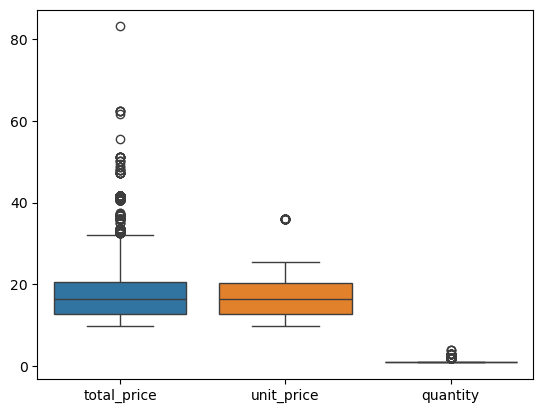

In [27]:
import seaborn as sns
sns.boxplot(data =df[['total_price','unit_price','quantity']])

# Sub_plot

In [ ]:
# find total salary,total absence rate,average